# Self Organizing Maps
___

In [61]:
#Library Import
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.metrics.pairwise import euclidean_distances
import random
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

#### Code

In [17]:
def normalise(train, p):
    min_d = np.min(train)
    max_d = np.max(train)
    normalised_p = (p-min_d)/(max_d - min_d)
    return normalised_p

def denormalise(train, p):
    min_d = np.min(train)
    max_d = np.max(train)
    denormalised_p = p * (max_d - min_d) + min_d
    return denormalised_p

# Return the (g,h) index of the BMU in the grid
def find_BMU(SOM,x):
    distSq = (np.square(SOM - x)).sum(axis=2)
    return np.unravel_index(np.argmin(distSq, axis=None), distSq.shape)

# Update the weights of the SOM cells when given a single training example
# and the model parameters along with BMU coordinates as a tuple
def update_weights(SOM, train_ex, learn_rate, radius_sq, 
                   BMU_coord, step=3):
    g, h = BMU_coord
    #if radius is close to zero then only BMU is changed
    if radius_sq < 1e-3:
        SOM[g,h,:] += learn_rate * (train_ex - SOM[g,h,:])
        return SOM
    # Change all cells in a small neighborhood of BMU
    for i in range(max(0, g-step), min(SOM.shape[0], g+step)):
        for j in range(max(0, h-step), min(SOM.shape[1], h+step)):
            dist_sq = np.square(i - g) + np.square(j - h)
            dist_func = np.exp(-dist_sq / 2 / radius_sq)
            SOM[i,j,:] += learn_rate * dist_func * (train_ex - SOM[i,j,:])   
    return SOM    

# Main routine for training an SOM. It requires an initialized SOM grid
# or a partially trained grid as parameter
def train_SOM_with_progress(SOM, train_data, learn_rate=0.1, radius_sq=1, 
                            lr_decay=0.1, radius_decay=0.1, epochs=10):    
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    
    # Iterate over epochs with a progress bar
    for epoch in tqdm(range(epochs), desc="Training SOM", unit="epoch"):
        np.random.shuffle(train_data)  # Shuffle the training data
        
        for train_ex in train_data:
            g, h = find_BMU(SOM, train_ex)
            SOM = update_weights(SOM, train_ex, learn_rate, radius_sq, (g,h))
        
        # Update learning rate and radius for the next epoch
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)
    
    return SOM

# Function to reshape SOM cell vectors into a 2D grid for visualization
def reshape_SOM_cell(SOM_cell, width=16, height=32):
    return SOM_cell.reshape((height, width))

In [26]:
# Function to calculate Quantization Error (QE)
def calculate_quantization_error(SOM, train_data):
    qe = 0
    for train_ex in train_data:
        g, h = find_BMU(SOM, train_ex)  # BMU (Best Matching Unit)
        qe += np.linalg.norm(train_ex - SOM[g, h])  # Distance to BMU
    qe /= len(train_data)  # Average error
    return qe

# Function to calculate Topological Error (TE)
def calculate_topological_error(SOM, train_data):
    te = 0
    for train_ex in train_data:
        g, h = find_BMU(SOM, train_ex)  # BMU (Best Matching Unit)
        
        # Check the 4 neighbors (up, down, left, right)
        neighbors = [
            (g - 1, h), (g + 1, h), (g, h - 1), (g, h + 1)
        ]
        for ng, nh in neighbors:
            if 0 <= ng < SOM.shape[0] and 0 <= nh < SOM.shape[1]:
                distance = np.linalg.norm(SOM[g, h] - SOM[ng, nh])
                if distance > 1.0:  # You can adjust this threshold
                    te += 1
    te /= len(train_data)  # Normalize by the number of examples
    return te

# Function to train SOM and track errors
def train_SOM_with_errors(SOM, train_data, learn_rate=0.1, radius_sq=1, 
                          lr_decay=0.1, radius_decay=0.1, epochs=100):
    quantization_errors = []
    topological_errors = []
    
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    
    # Use tqdm to show the progress bar for epochs
    for epoch in tqdm(range(epochs), desc="Training SOM", ncols=100, leave=True):
        random.shuffle(train_data)  # Shuffle the training data for each epoch      
        for train_ex in train_data:
            g, h = find_BMU(SOM, train_ex)
            SOM = update_weights(SOM, train_ex, learn_rate, radius_sq, (g, h))
        
        # Update learning rate and radius
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)            
        
        # Track errors for each epoch
        quantization_errors.append(calculate_quantization_error(SOM, train_data))
        topological_errors.append(calculate_topological_error(SOM, train_data))
        
    return SOM, quantization_errors, topological_errors

In [53]:
# Function to apply PCA to reduce dimensionality
def apply_pca(data, n_components=3):
    pca = PCA(n_components=n_components)
    pca.fit(data)
    return pca

# Function to visualize the SOM with PCA components
def visualize_SOM_with_PCA(SOM, image_vectors, n_components=3):
    # Step 1: Fit PCA to the entire training set (image vectors)
    pca_full = apply_pca(image_vectors, n_components=n_components)
    
    # Step 2: Apply PCA to the SOM grid cells (oSOM is the denormalized SOM)
    pca_SOM = apply_pca(SOM.reshape(-1, SOM.shape[2]), n_components=n_components)
    
    # Step 3: Create the grid for displaying the SOM
    fig, ax = plt.subplots(figsize=(12, 12))
    grid_width, grid_height = SOM.shape[0], SOM.shape[1]

    # Ensure the SOM grid is 30x30
    if grid_width != 30 or grid_height != 30:
        raise ValueError("SOM grid must be 30x30 to display 900 images")

    # Loop through the grid and assign the PCA components to each SOM cell
    for i in range(grid_width):
        for j in range(grid_height):
            # Get the SOM cell vector
            som_cell_vector = oSOM[i, j]
            
            # Apply the PCA transformation to the SOM cell
            pca_transformed_cell = pca_SOM.transform(som_cell_vector.reshape(1, -1))

            # Map the PCA components to RGB values
            # Normalize the PCA components to [0, 1] for RGB mapping
            rgb_value = (pca_transformed_cell - np.min(pca_transformed_cell)) / (np.max(pca_transformed_cell) - np.min(pca_transformed_cell))
            
            # Display the cell with the computed RGB value
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=rgb_value[0]))
    
    # Adjust ticks and labels
    ax.set_xticks(np.arange(grid_height + 1))
    ax.set_yticks(np.arange(grid_width + 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f'Trained SOM Grid with PCA components (RGB)')

    plt.tight_layout()
    plt.show()

In [57]:
def display_SOM_with_closest_images(SOM, image_vectors, original_images, grid_width=30, grid_height=30):
    """
    Function to display the SOM grid where each cell is represented by the closest image to that cell's vector.
    
    Parameters:
        SOM: 2D numpy array (grid_width, grid_height, n_features) - Trained SOM grid.
        image_vectors: 2D numpy array (n_images, n_features) - Feature vectors of the images.
        original_images: List of PIL Image objects corresponding to the original images.
        grid_width: int - Width of the SOM grid.
        grid_height: int - Height of the SOM grid.
    """
    # Create the grid to display the SOM
    fig, ax = plt.subplots(figsize=(12, 12))

    # Loop through the grid and display the closest image to each SOM cell
    for i in range(grid_width):
        for j in range(grid_height):
            # Get the SOM cell vector
            som_cell_vector = SOM[i, j]

            # Find the closest image to the current SOM cell
            distances = np.linalg.norm(image_vectors - som_cell_vector, axis=1)
            closest_image_index = np.argmin(distances)

            # Get the corresponding image
            img = original_images[closest_image_index]

            # Resize the image to fit into the grid
            img_resized = img.resize((50, 50))  # Resize the image to fit the grid cell

            # Display the image in the grid
            ax.imshow(img_resized, extent=(j, j + 1, i, i + 1))

    # Remove ticks and labels
    ax.set_xticks(np.arange(grid_height))
    ax.set_yticks(np.arange(grid_width))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title('Trained SOM Grid with Closest Images')

    plt.tight_layout()
    plt.show()

In [66]:
def activation_overlay_on_SOM_grid(SOM, input_vector, grid_width=30, grid_height=30):
    """
    Function to display the SOM grid with activation color overlay based on the input vector.
    The activation is color-mapped from white to olive green.

    Parameters:
        SOM: 2D numpy array (grid_width, grid_height, n_features) - Trained SOM grid.
        input_vector: 1D numpy array (n_features,) - The input vector for activation.
        grid_width: int - Width of the SOM grid.
        grid_height: int - Height of the SOM grid.
    """
    # Calculate activations for each SOM cell based on input vector
    activations = np.zeros((grid_width, grid_height))
    for i in range(grid_width):
        for j in range(grid_height):
            som_cell_vector = SOM[i, j]
            # Calculate Euclidean distance between input vector and the SOM cell
            activations[i, j] = np.linalg.norm(input_vector - som_cell_vector)

    # Normalize activations to the range [0, 1] for color mapping
    activations = activations / np.max(activations)

    # Create a custom colormap from white to olive green
    colors = [(1.0, 1.0, 1.0), (0.33, 0.42, 0.18)]  # White to olive green
    cmap = LinearSegmentedColormap.from_list("white_to_olive", colors, N=256)

    # Create the grid to display the SOM with activation overlay
    fig, ax = plt.subplots(figsize=(12, 12))

    # Display the SOM with color map based on activations
    ax.imshow(activations, cmap=cmap, interpolation='nearest')

    # Remove ticks and labels
    ax.set_xticks(np.arange(grid_height))
    ax.set_yticks(np.arange(grid_width))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title('SOM Activation Overlay (White to Olive Green)')

    plt.tight_layout()
    plt.show()

#### Load Image Vectors

In [10]:
# Load the image vectors from the pickle file
pickle_path = os.path.join ("Pickle","image_vectors2.pkl")
with open(pickle_path, "rb") as f:
    image_vectors = pickle.load(f)

# Verify that the data is loaded correctly
print(f"Shape of image vectors: {image_vectors.shape}")

Shape of image vectors: (991, 512)


#### Execute

1. SOM Train

In [46]:
m, n = 30, 30  # SOM grid dimensions
SOM = np.random.rand(m, n, n_train_data.shape[1])  # Initialize SOM grid with random values

In [47]:
n_train_data = np.array([normalise(image_vectors, vec) for vec in image_vectors])

In [48]:
SOM, quantization_errors, topological_errors = train_SOM_with_errors(
    SOM, n_train_data,
    learn_rate=0.2, radius_sq=6,
    lr_decay=0.995, radius_decay=0.95,
    epochs=1000
)


Training SOM: 100%|███████████████████████████████████████████| 1000/1000 [1:11:05<00:00,  4.27s/it]


2. Save SOM Training

In [51]:
# Save the trained SOM to a pickle file
with open("trained_SOM_1000epochs_30x30.pkl", "wb") as f:
    pickle.dump(SOM, f)

# Optionally save the errors as well, if needed
with open("quantization_errors_1000epochs.pkl", "wb") as f:
    pickle.dump(quantization_errors, f)

with open("topological_errors_1000epochs.pkl", "wb") as f:
    pickle.dump(topological_errors, f)

3. Display SOM Result

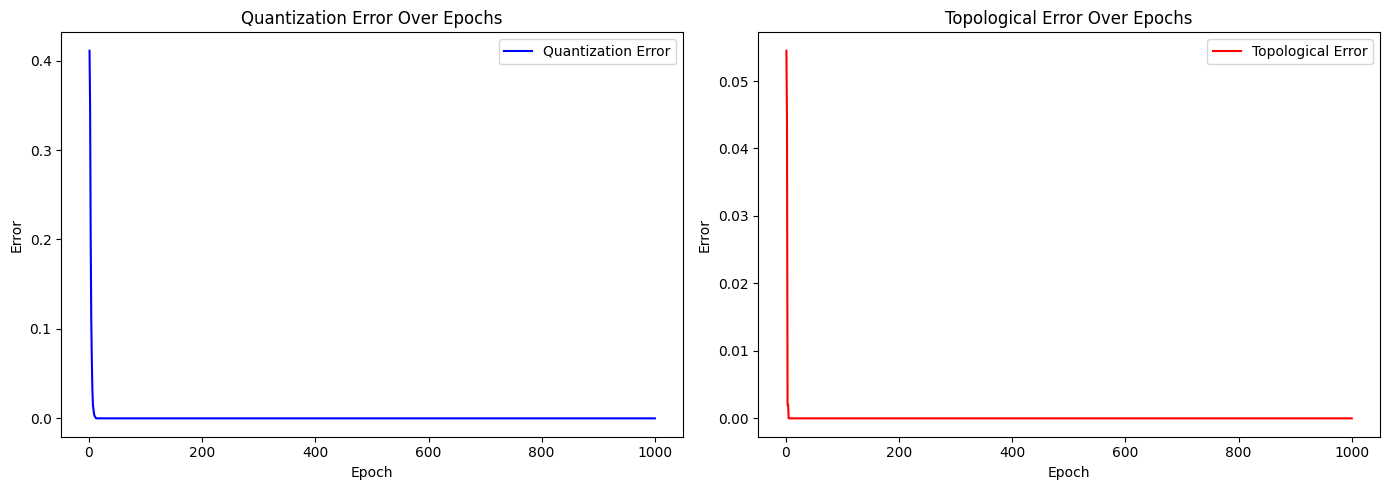

In [49]:
# Plot the Quantization and Topological Error over epochs
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Quantization Error plot
ax[0].plot(np.arange(1, 1001), quantization_errors, label='Quantization Error', color='b')  # Changed to 1001
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Error')
ax[0].set_title('Quantization Error Over Epochs')
ax[0].legend()

# Topological Error plot
ax[1].plot(np.arange(1, 1001), topological_errors, label='Topological Error', color='r')  # Changed to 1001
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Error')
ax[1].set_title('Topological Error Over Epochs')
ax[1].legend()

plt.tight_layout()
plt.show()


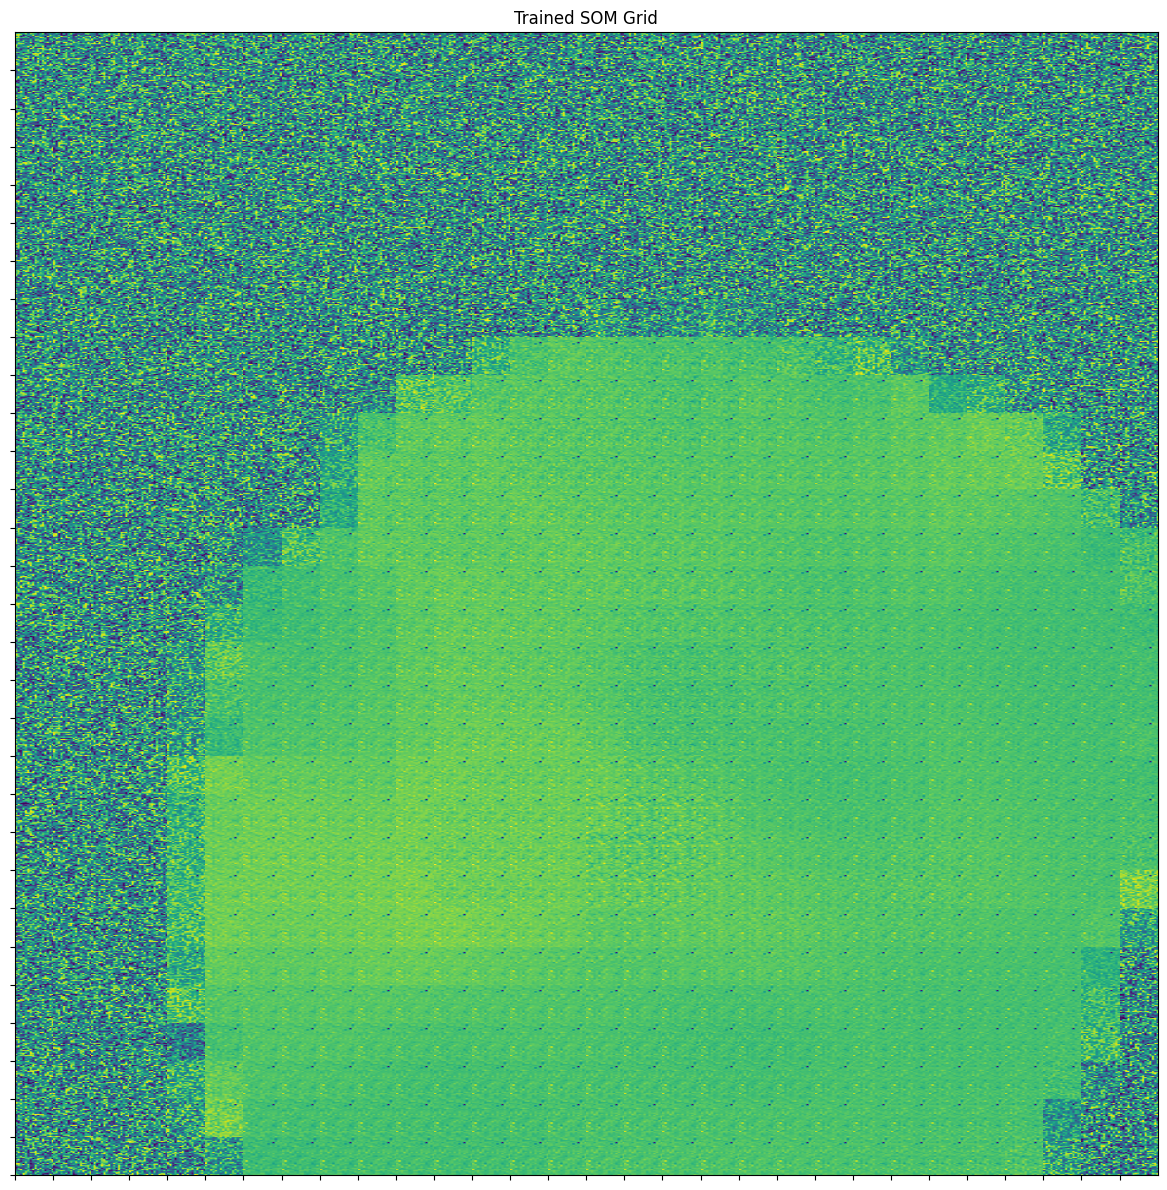

In [50]:
# Denormalize the SOM to the original scale
oSOM = denormalise(image_vectors, SOM)

# Create a grid to display the SOM
fig, ax = plt.subplots(figsize=(12, 12))

grid_width, grid_height = SOM.shape[0], SOM.shape[1]

# Ensure SOM grid is 30x30
if grid_width != 30 or grid_height != 30:
    raise ValueError("SOM grid must be 30x30 to display 900 images")

# Loop through the grid and display each image
for i in range(grid_width):
    for j in range(grid_height):
        # Reshape the SOM cell vector into a 2D image (make sure to define reshape_SOM_cell properly)
        som_cell_image = reshape_SOM_cell(oSOM[i, j])  # Ensure this function is working as expected
        ax.imshow(som_cell_image, extent=(j, j + 1, i, i + 1))

# Adjust the ticks and labels
ax.set_xticks(np.arange(grid_height))
ax.set_yticks(np.arange(grid_width))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_title('Trained SOM Grid')

plt.tight_layout()
plt.show()


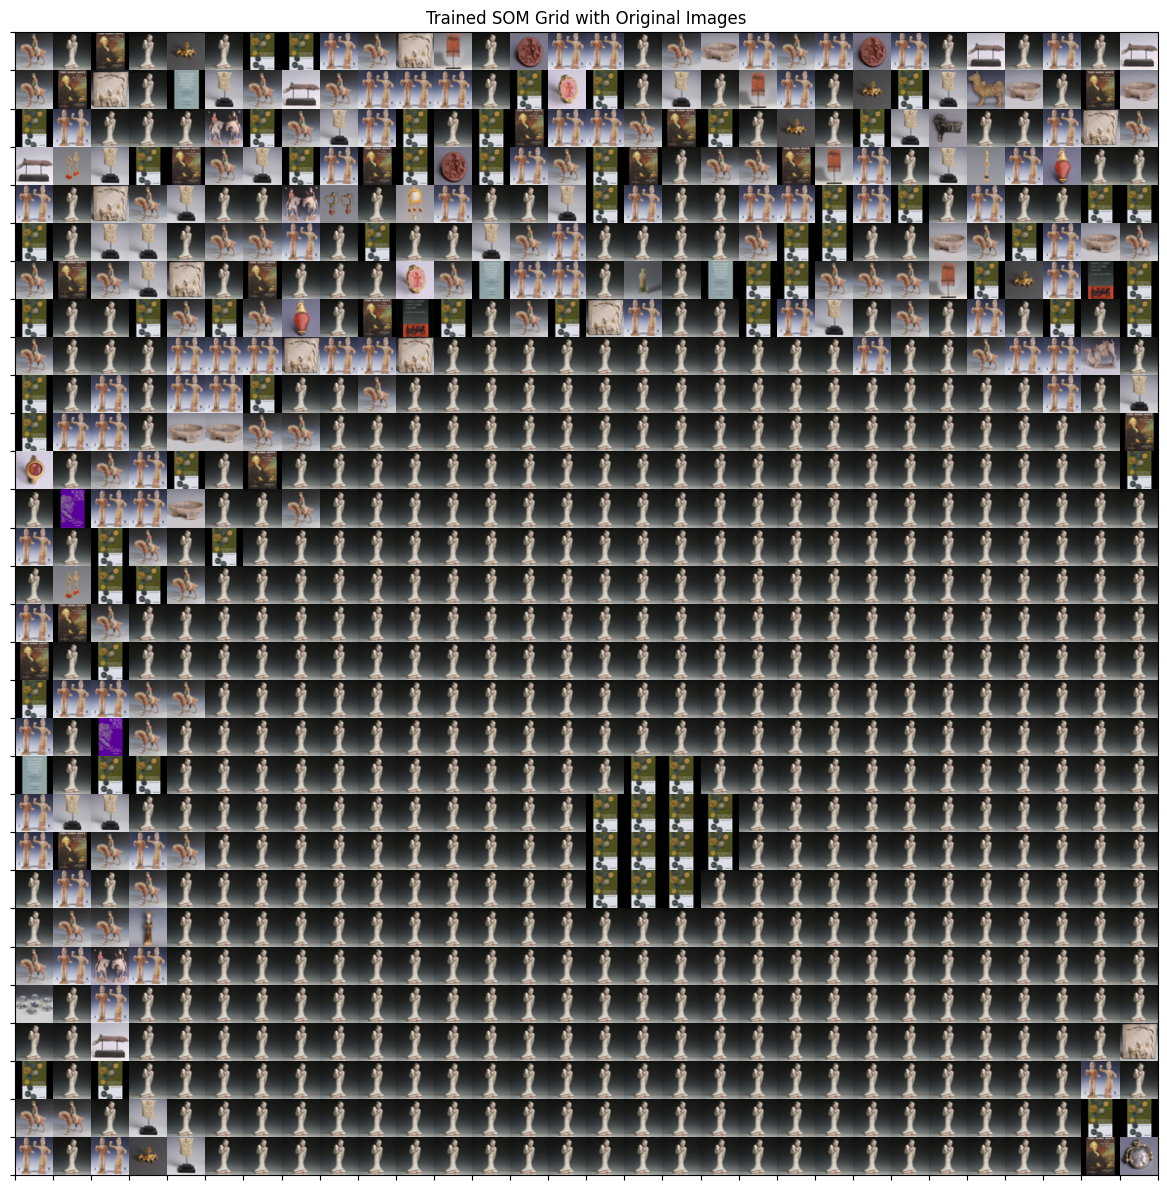

In [52]:
# Directory where the original images are stored
image_folder = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\Datasets\Antiques\Antiques"

# Load the original images
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]
image_paths = [os.path.join(image_folder, f) for f in image_files]
original_images = [Image.open(p) for p in image_paths]

# After training, the SOM grid (assume it's the variable `SOM` from your training)
# and the normalized data (`n_train_data`).

# Denormalize the SOM to the original scale
oSOM = denormalise(image_vectors, SOM)  # Ensure `denormalise` is defined correctly

# Create a grid to display the SOM
fig, ax = plt.subplots(figsize=(12, 12))

# Dimensions of the SOM grid
grid_width, grid_height = SOM.shape[0], SOM.shape[1]

# Ensure the SOM grid is 30x30
if grid_width != 30 or grid_height != 30:
    raise ValueError("SOM grid must be 30x30 to display 900 images")

# Find the closest image for each SOM grid cell
for i in range(grid_width):
    for j in range(grid_height):
        # Find the index of the closest image vector
        distances = np.linalg.norm(image_vectors - SOM[i, j], axis=1)
        closest_image_index = np.argmin(distances)
        
        # Get the corresponding image
        img = original_images[closest_image_index]
        
        # Resize the image to fit into the grid cell
        img_resized = img.resize((40, 40))  # Adjust size to fit better into the grid
        
        # Display the image in the grid
        ax.imshow(np.array(img_resized), extent=(j, j + 1, i, i + 1))

# Remove ticks and labels
ax.set_xticks(np.arange(grid_height + 1))
ax.set_yticks(np.arange(grid_width + 1))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_title('Trained SOM Grid with Original Images')

# Display the grid
plt.tight_layout()
plt.show()

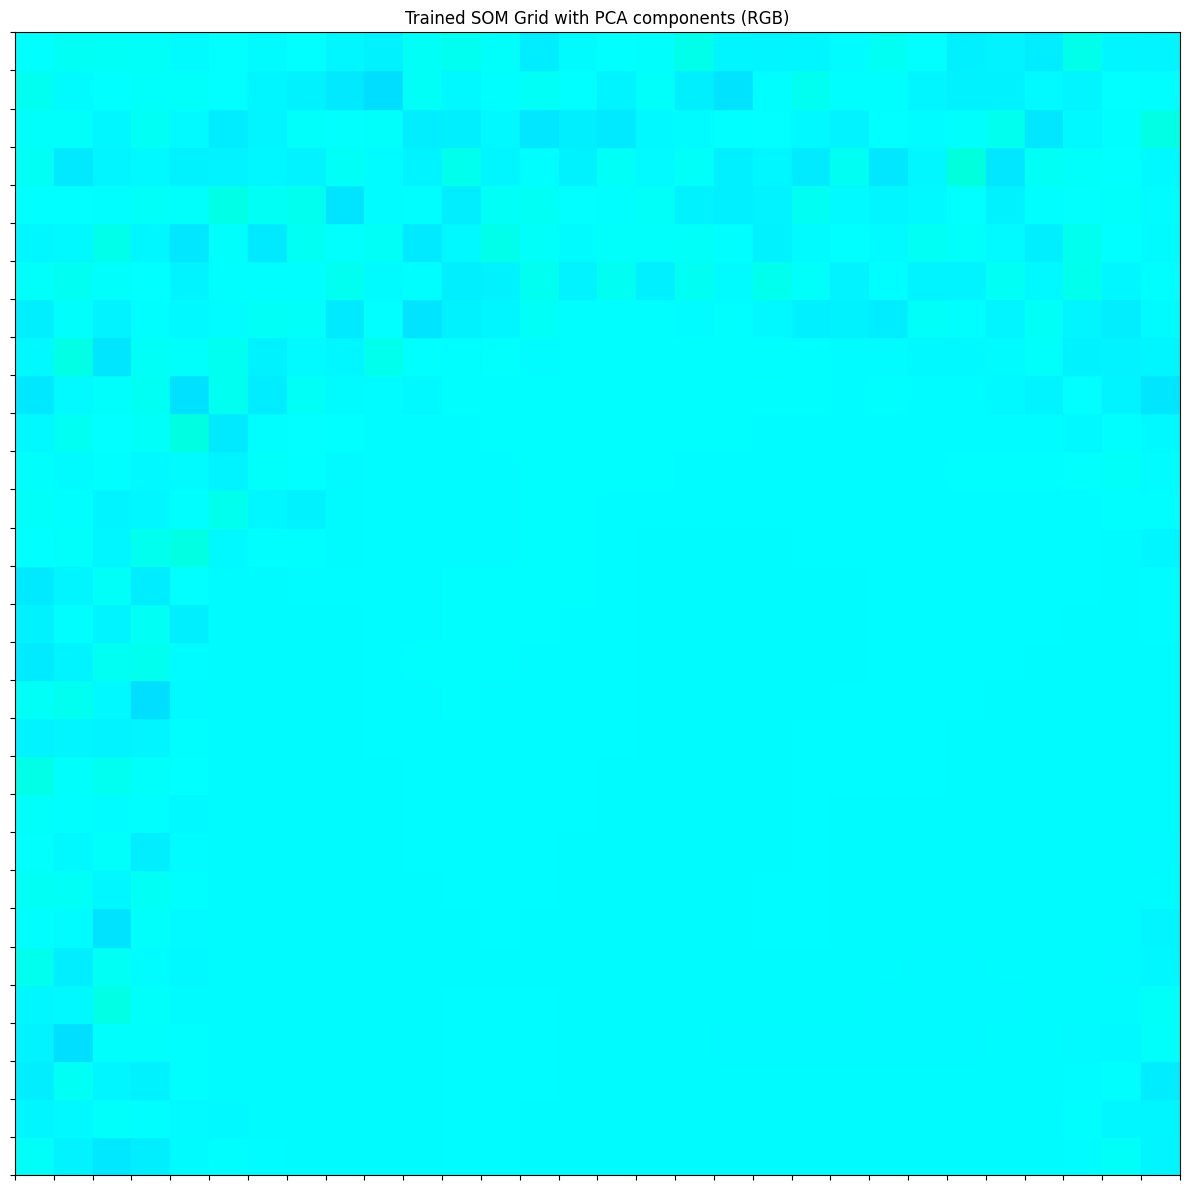

In [56]:
# Assuming oSOM is the denormalized SOM and image_vectors is your original dataset
visualize_SOM_with_PCA(SOM, image_vectors)

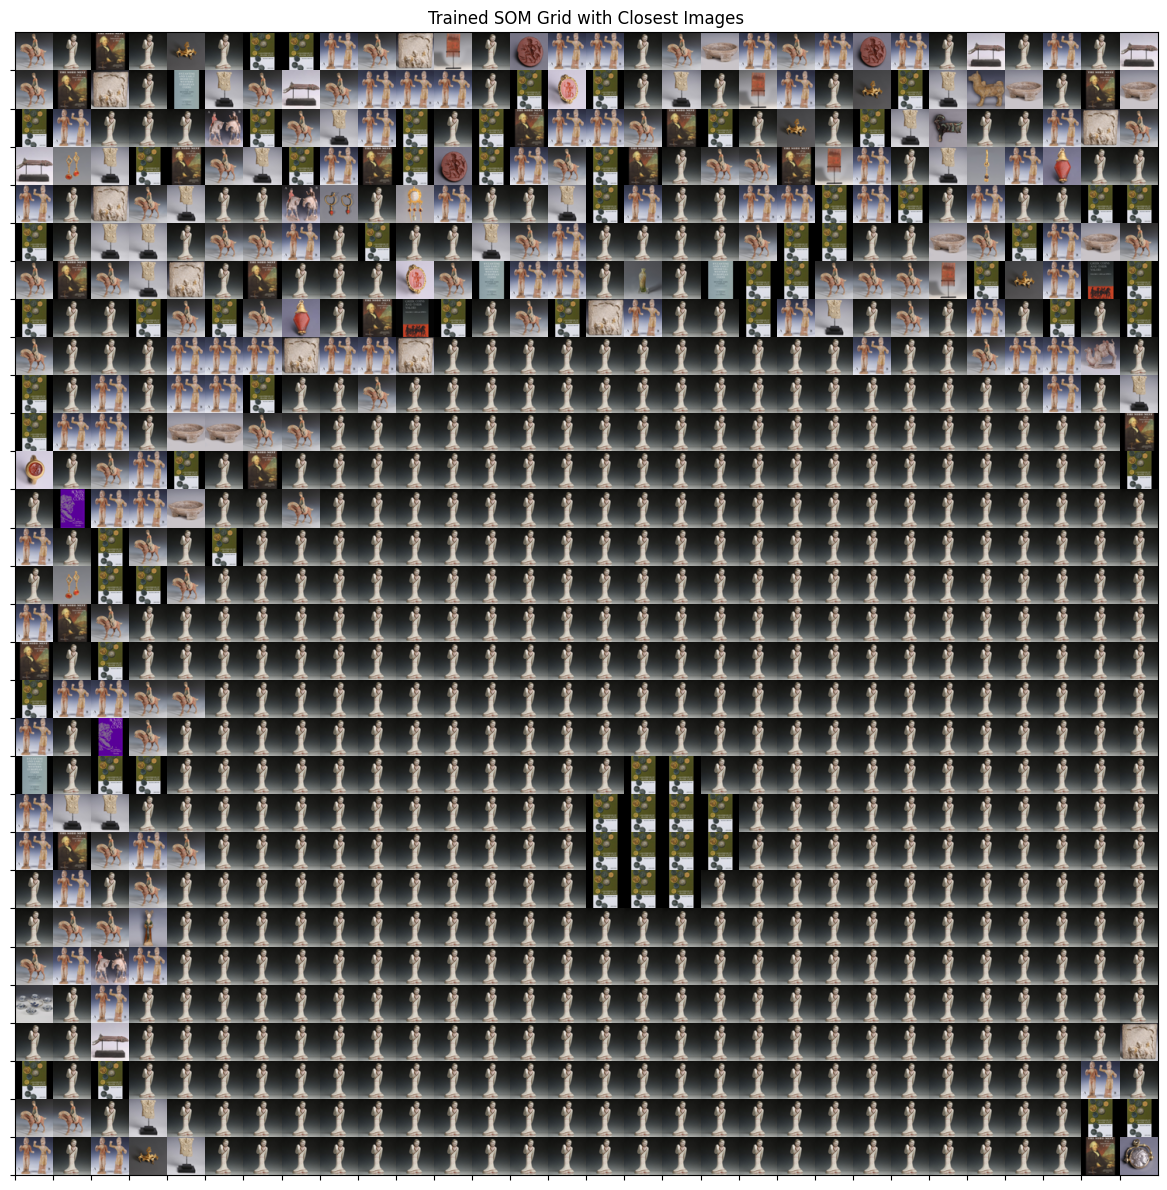

In [58]:
# directory where the original images are stored
image_folder = r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\Datasets\Antiques\Antiques"

# Load the original images
image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg') or f.endswith('.png')]
image_paths = [os.path.join(image_folder, f) for f in image_files]
original_images = [Image.open(p) for p in image_paths]

# Call the function to display the SOM with the closest images
display_SOM_with_closest_images(SOM, image_vectors, original_images)

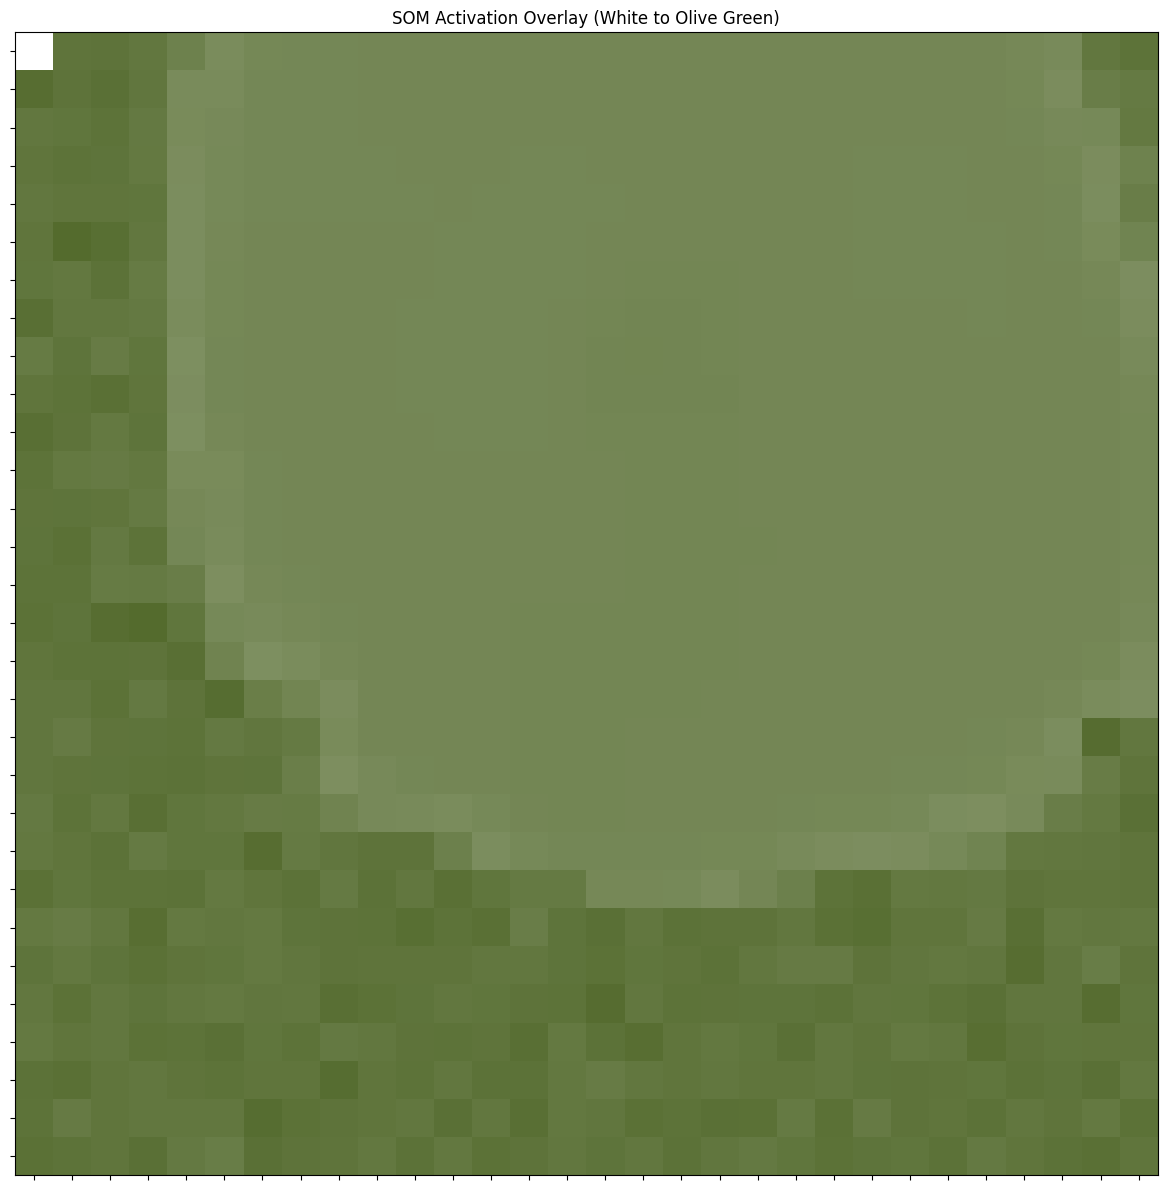

In [67]:
# Define a sample input vector (this can be a random or specific vector from your dataset)
input_vector = SOM[0, 0]  # Or choose another vector

# Call the function to display the SOM with activation overlay
activation_overlay_on_SOM_grid(SOM, input_vector)